# Task 7: Time Series Analysis

## Objective
Analyze stock price data to identify trends, seasonality, and time-based patterns.

### Dataset
Historical Stock Price Dataset (`HistoricalQuotes.csv`)

### Tools Used
- Python
- Pandas
- Matplotlib
- NumPy
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside notebook
%matplotlib inline

## Step 1: Load the Dataset
Load the stock price dataset into a Pandas DataFrame.

In [2]:
df = pd.read_csv("C:/Users/User/Desktop/Time Series Analysis/Dataset/HistoricalQuotes.csv")

df.head()

,Date,Close/Last,Volume,Open,High,Low
0,02/28/2020,$273.36,106721200,$257.26,$278.41,$256.37
1,02/27/2020,$273.52,80151380,$281.1,$286,$272.96
2,02/26/2020,$292.65,49678430,$286.53,$297.88,$286.5
3,02/25/2020,$288.08,57668360,$300.95,$302.53,$286.13
4,02/24/2020,$298.18,55548830,$297.26,$304.18,$289.23


## Step 2: Explore the Dataset
Check the structure, data types, and missing values.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         2518 non-null   str  
 1    Close/Last  2518 non-null   str  
 2    Volume      2518 non-null   int64
 3    Open        2518 non-null   str  
 4    High        2518 non-null   str  
 5    Low         2518 non-null   str  
dtypes: int64(1), str(5)
memory usage: 118.2 KB


In [4]:
df.describe()

,Volume
count,2.518000e+03
mean,7.258009e+07
std,5.663113e+07
min,1.136205e+07
25%,3.053026e+07
50%,5.295469e+07
75%,9.861006e+07
max,4.624423e+08


In [5]:
df.isnull().sum()

Date           0
 Close/Last    0
 Volume        0
 Open          0
 High          0
 Low           0
dtype: int64

## Step 3: Data Cleaning
Clean the dataset by:

- Removing extra spaces from column names
- Removing '$' symbols
- Converting price columns to numeric values
- Converting Date column to datetime format
- Sorting records by date

In [6]:
# Remove spaces from column names
df.columns = df.columns.str.strip()

# Price columns
price_columns = ["Close/Last", "Open", "High", "Low"]

# Remove "$" and convert to float
for col in price_columns:
    df[col] = df[col].replace(r'[\$,]', '', regex=True).astype(float)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Sort by Date
df = df.sort_values("Date")

df.head()

,Date,Close/Last,Volume,Open,High,Low
2517,2010-03-01,29.8557,137312041,29.3928,29.9286,29.3500
2516,2010-03-02,29.8357,141486282,29.9900,30.1186,29.6771
2515,2010-03-03,29.9043,92846488,29.8486,29.9814,29.7057
2514,2010-03-04,30.1014,89591907,29.8971,30.1314,29.8043
2513,2010-03-05,31.2786,224647427,30.7057,31.3857,30.6614


## Step 4: Set Date as Index
The Date column is used as the index for time series analysis.

In [7]:
df.set_index("Date", inplace=True)

df.head()

,Close/Last,Volume,Open,High,Low
Date,,,,,
2010-03-01,29.8557,137312041,29.3928,29.9286,29.3500
2010-03-02,29.8357,141486282,29.9900,30.1186,29.6771
2010-03-03,29.9043,92846488,29.8486,29.9814,29.7057
2010-03-04,30.1014,89591907,29.8971,30.1314,29.8043
2010-03-05,31.2786,224647427,30.7057,31.3857,30.6614


## Step 5: Plot Closing Price Trend
Visualize how the closing stock price changes over time.

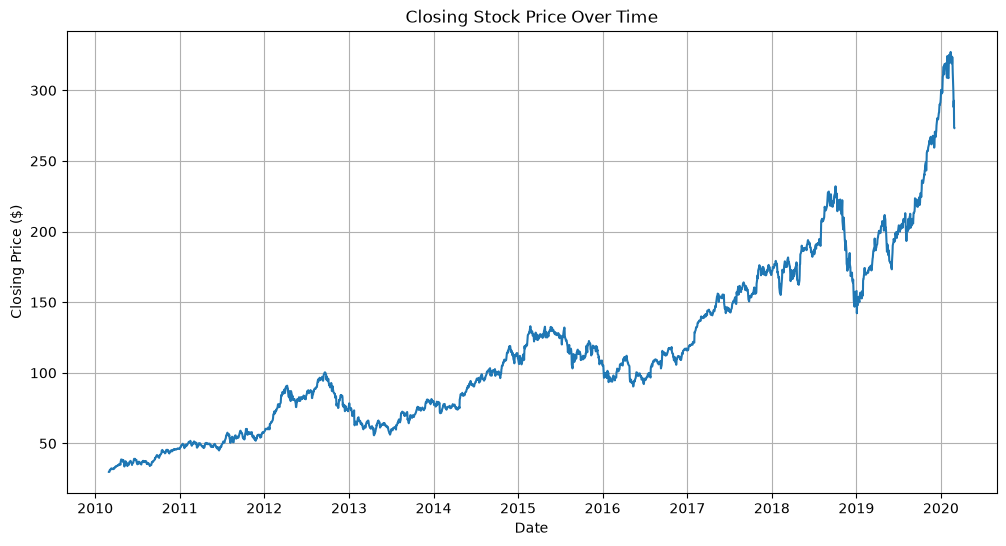

In [8]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close/Last"])

plt.title("Closing Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.grid(True)

plt.show()

## Step 6: Calculate 30-Day Moving Average
The moving average helps smooth short-term fluctuations and highlights the overall trend.

In [9]:
df["30-Day MA"] = df["Close/Last"].rolling(window=30).mean()

df.head()

,Close/Last,Volume,Open,High,Low,30-Day MA
Date,,,,,,
2010-03-01,29.8557,137312041,29.3928,29.9286,29.3500,NaN
2010-03-02,29.8357,141486282,29.9900,30.1186,29.6771,NaN
2010-03-03,29.9043,92846488,29.8486,29.9814,29.7057,NaN
2010-03-04,30.1014,89591907,29.8971,30.1314,29.8043,NaN
2010-03-05,31.2786,224647427,30.7057,31.3857,30.6614,NaN


## Step 7: Compare Closing Price with Moving Average

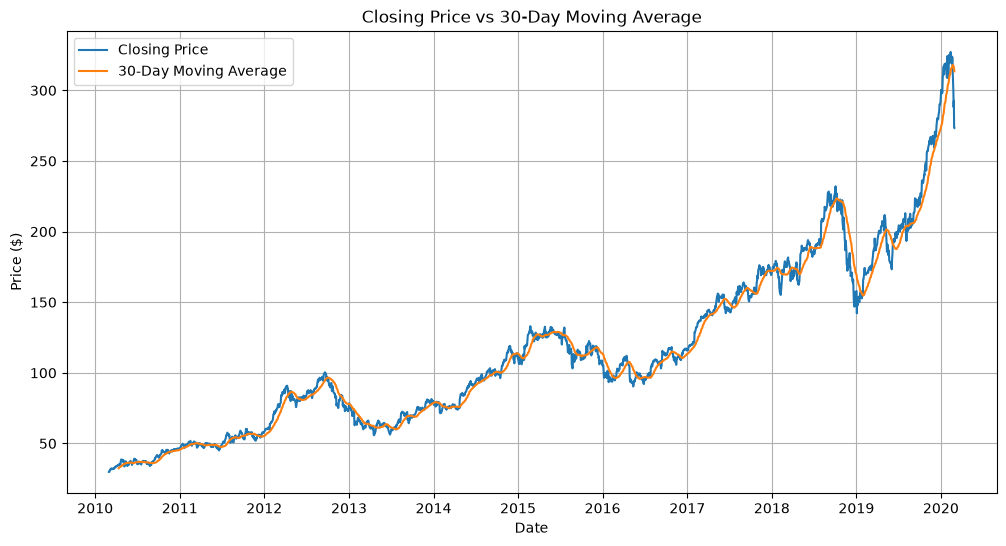

In [10]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close/Last"], label="Closing Price")
plt.plot(df.index, df["30-Day MA"], label="30-Day Moving Average")

plt.title("Closing Price vs 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()

plt.grid(True)

plt.show()

## Step 8: Monthly Average Closing Price
Analyze average stock prices by month.

In [12]:
monthly_avg = df["Close/Last"].resample("ME").mean()

monthly_avg.head()

Date
2010-03-31    31.915791
2010-04-30    35.878352
2010-05-31    35.923015
2010-06-30    37.306545
2010-07-31    36.421338
Freq: ME, Name: Close/Last, dtype: float64

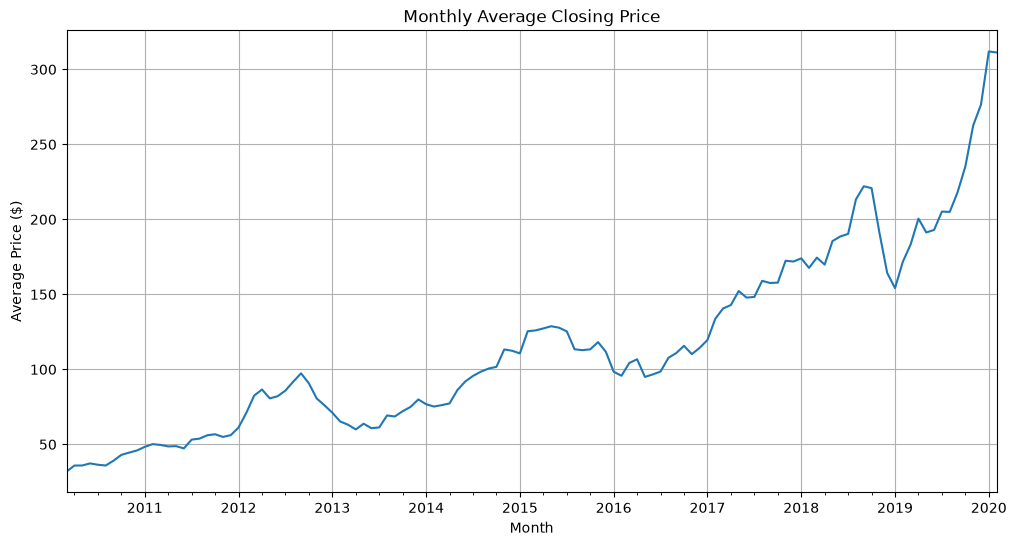

In [13]:
plt.figure(figsize=(12,6))

monthly_avg.plot()

plt.title("Monthly Average Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Price ($)")
plt.grid(True)

plt.show()

## Step 9: Summary of Analysis

### Observations

- The stock price changes over time.
- The moving average smooths daily fluctuations.
- Monthly averages help identify long-term trends.
- Time series visualization provides insights into stock performance.

## Step 10: Yearly Average Closing Price

Analyze the average closing stock price for each year to understand long-term trends.

In [14]:
yearly_avg = df["Close/Last"].resample("YE").mean()

yearly_avg

Date
2010-12-31     38.555780
2011-12-31     52.000600
2012-12-31     82.292795
2013-12-31     67.519240
2014-12-31     92.264550
2015-12-31    120.039861
2016-12-31    104.604008
2017-12-31    150.551056
2018-12-31    189.053426
2019-12-31    208.255933
2020-12-31    311.609500
Freq: YE-DEC, Name: Close/Last, dtype: float64

## Step 11: Visualize Yearly Trend

This chart shows how the average stock price changes from year to year.

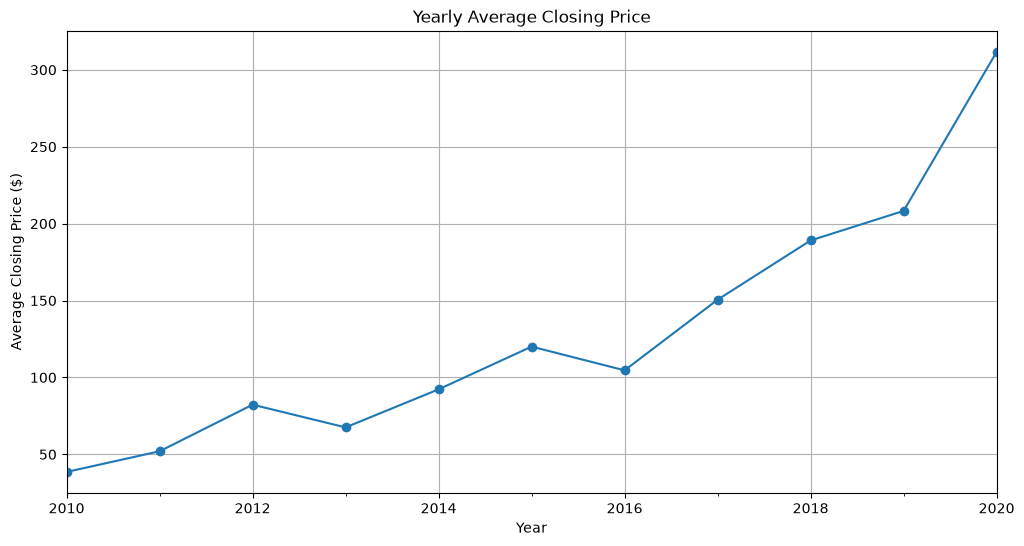

In [15]:
plt.figure(figsize=(12,6))

yearly_avg.plot(marker="o")

plt.title("Yearly Average Closing Price")
plt.xlabel("Year")
plt.ylabel("Average Closing Price ($)")
plt.grid(True)

plt.show()

## Step 12: Rolling Statistics

Rolling statistics help smooth fluctuations and reveal the underlying trend.

In [16]:
df["Rolling Mean"] = df["Close/Last"].rolling(window=30).mean()
df["Rolling Std"] = df["Close/Last"].rolling(window=30).std()

df.head()

,Close/Last,Volume,Open,High,Low,30-Day MA,Rolling Mean,Rolling Std
Date,,,,,,,,
2010-03-01,29.8557,137312041,29.3928,29.9286,29.3500,NaN,NaN,NaN
2010-03-02,29.8357,141486282,29.9900,30.1186,29.6771,NaN,NaN,NaN
2010-03-03,29.9043,92846488,29.8486,29.9814,29.7057,NaN,NaN,NaN
2010-03-04,30.1014,89591907,29.8971,30.1314,29.8043,NaN,NaN,NaN
2010-03-05,31.2786,224647427,30.7057,31.3857,30.6614,NaN,NaN,NaN


## Step 13: Plot Rolling Mean and Rolling Standard Deviation

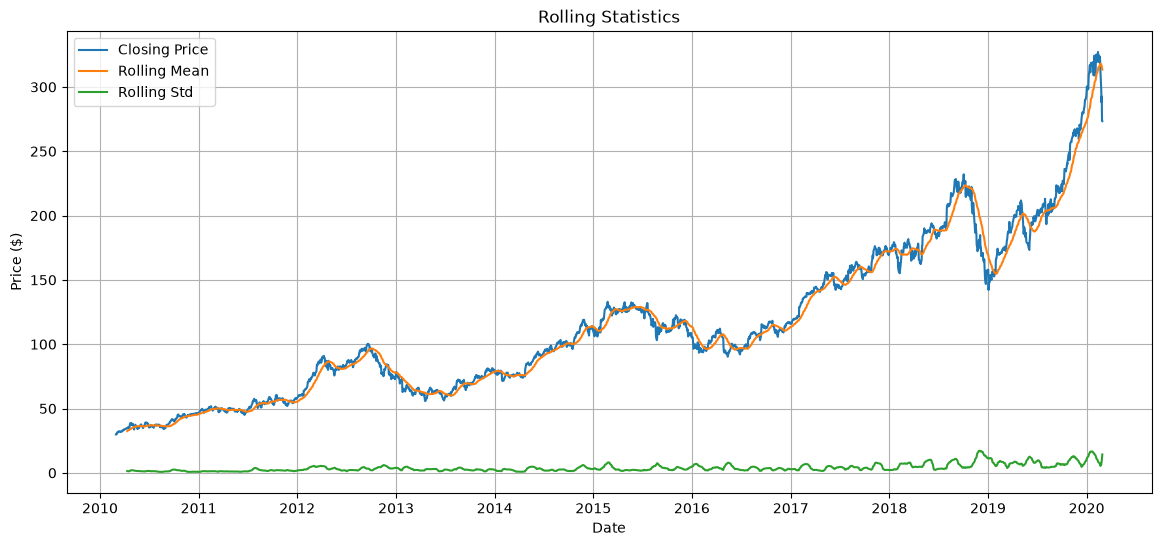

In [17]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df["Close/Last"], label="Closing Price")
plt.plot(df.index, df["Rolling Mean"], label="Rolling Mean")
plt.plot(df.index, df["Rolling Std"], label="Rolling Std")

plt.title("Rolling Statistics")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()

plt.grid(True)

plt.show()

## Step 14: Key Insights

### Observations

- The stock price shows fluctuations over time.
- The rolling mean smooths short-term fluctuations and highlights the long-term trend.
- The rolling standard deviation indicates the variability of stock prices.
- Yearly average prices provide insight into long-term market performance.

# Step 15: Forecast Future Stock Prices (Optional)

In this step, we use the ARIMA (AutoRegressive Integrated Moving Average) model to forecast future stock prices based on historical closing prices.

In [19]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 6.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.6 MB 5.8 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.6 MB 3.3 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.6 MB 3.4 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.6 MB 3.2 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 3.2 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.6 MB 2.6 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.5 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.6 MB 2.3 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.6 MB 2.3 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.6 MB 2.0 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.6 MB 2.0 MB/s eta 0:00:03
   ----------------


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from statsmodels.tsa.arima.model import ARIMA

## Step 16: Train the ARIMA Model

We train the ARIMA model using the historical closing prices.

In [21]:
model = ARIMA(df["Close/Last"], order=(5,1,0))

model_fit = model.fit()

print(model_fit.summary())

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Close/Last   No. Observations:                 2518
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -5425.188
Date:                Mon, 03 Aug 2026   AIC                          10862.377
Time:                        21:44:59   BIC                          10897.362
Sample:                             0   HQIC                         10875.073
                               - 2518                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0172      0.012      1.468      0.142      -0.006       0.040
ar.L2         -0.0329      0.012     -2.812      0.005      -0.056      -0.010
ar.L3         -0.0212      0.011     -1.924      0.0

## Step 17: Forecast the Next 30 Days

Generate predictions for the next 30 trading periods.

In [22]:
forecast = model_fit.forecast(steps=30)

forecast

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


2518    272.472630
2519    272.787556
2520    271.543979
2521    270.698421
2522    270.642758
2523    270.682243
2524    270.620109
2525    270.500290
2526    270.458885
2527    270.464096
2528    270.464980
2529    270.453781
2530    270.445114
2531    270.443942
2532    270.444736
2533    270.444145
2534    270.442984
2535    270.442504
2536    270.442558
2537    270.442587
2538    270.442481
2539    270.442390
2540    270.442375
2541    270.442385
2542    270.442381
2543    270.442369
2544    270.442364
2545    270.442364
2546    270.442365
2547    270.442364
Name: predicted_mean, dtype: float64

## Step 18: Visualize Forecasted Prices

Compare the historical stock prices with the forecasted values.

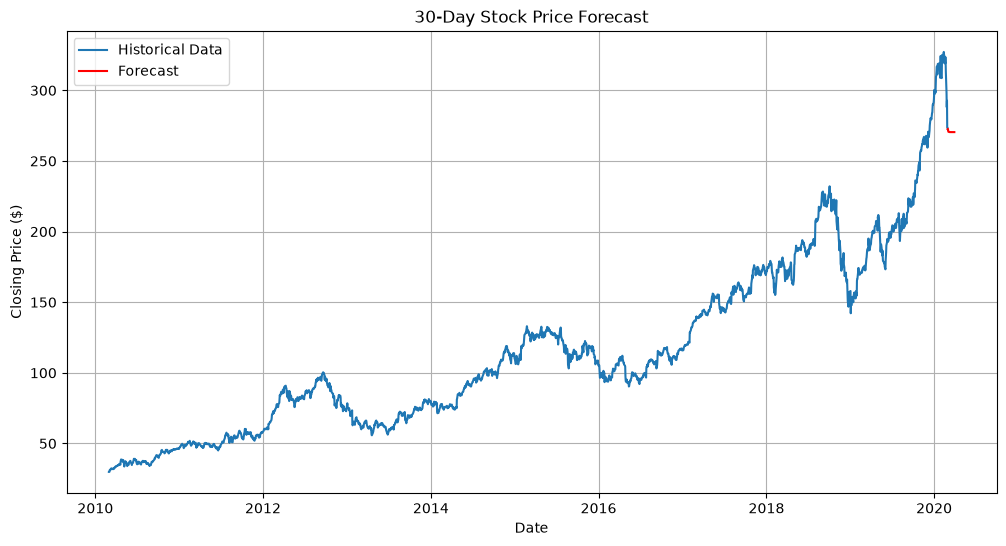

In [23]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Close/Last"], label="Historical Data")

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

plt.plot(future_dates, forecast, label="Forecast", color="red")

plt.title("30-Day Stock Price Forecast")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()

plt.grid(True)

plt.show()

# Conclusion

## Summary

- Loaded and cleaned the historical stock price dataset.
- Performed exploratory data analysis.
- Visualized stock price trends.
- Calculated a 30-day moving average.
- Analyzed monthly and yearly average prices.
- Examined rolling statistics.
- Built an ARIMA model to forecast future stock prices.

## Key Insights

- The stock price shows fluctuations over time.
- The moving average smooths short-term changes and highlights long-term trends.
- Monthly and yearly analyses reveal broader market behavior.
- The ARIMA model provides an estimate of future stock prices based on historical data.